# Mini Project 1 Image Classification
## Step 3: EfficientNet-B0 (Pretrained + Fine-tuned)

**Strategy**: Transfer learning: load ImageNet-pretrained EfficientNet-B0, replace the classifier head with a 101-class output, then fine-tune the full network.

**Why EfficientNet-B0:**  
EfficientNet scales depth, width, and resolution together using a compound coefficient. B0 is the base model, fewer parameters than ResNet-18 but often more accurate due to better architectural efficiency (inverted residuals + squeeze-and-excitation blocks).

**Ablation studies** (same as ResNet for direct comparison):
- Image size: 64×64 vs 128×128
- Augmentation: with vs without

In [3]:
# ── Imports
import pickle
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)

# ── Reproducibility
SEED = 261
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: mps


In [4]:
# ── Load shared data from Step 1
with open("shared_data.pkl", "rb") as f:
    data = pickle.load(f)

train_paths          = data["train_paths"]
train_labels         = data["train_labels"]
val_paths            = data["val_paths"]
val_labels           = data["val_labels"]
test_paths           = data["test_paths"]
test_labels          = data["test_labels"]
class_names          = data["class_names"]
class_weights_tensor = data["class_weights_tensor"]

NUM_CLASSES = len(class_names)
print(f"Classes: {NUM_CLASSES} | Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Classes: 101 | Train: 6073 | Val: 1302 | Test: 1302


In [5]:
# ── Configuration
EPOCHS       = 50
BATCH_SIZE   = 32
NUM_WORKERS  = 0       # 0 for Mac compatibility
LR           = 1e-4    # Adam learning rate
WEIGHT_DECAY = 1e-4    # L2 regularization

# EfficientNet-B0 native resolution is 224×224 — same as ResNet ablation configs
ABLATION_CONFIGS = [
    {"name": "224_aug",    "img_size": 224, "augment": True},   # baseline
    {"name": "128_aug",    "img_size": 128, "augment": True},   # ablation: image size (128)
    {"name": "64_aug",     "img_size": 64,  "augment": True},   # ablation: image size (64)
    {"name": "224_no_aug", "img_size": 224, "augment": False},  # ablation: no augmentation
]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [6]:
# ── Dataset class
class Caltech101Dataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")  # handle greyscale/RGBA
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


def get_transforms(img_size, augment):
    """Return train and eval transforms for a given image size and augment flag."""
    base = [
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
    aug = [
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
        transforms.RandomResizedCrop(img_size, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
    train_tf = transforms.Compose(aug if augment else base)
    eval_tf  = transforms.Compose(base)  # eval always deterministic
    return train_tf, eval_tf


def get_loaders(img_size, augment):
    """Build DataLoaders for a given ablation config."""
    train_tf, eval_tf = get_transforms(img_size, augment)
    train_ds = Caltech101Dataset(train_paths, train_labels, transform=train_tf)
    val_ds   = Caltech101Dataset(val_paths,   val_labels,   transform=eval_tf)
    test_ds  = Caltech101Dataset(test_paths,  test_labels,  transform=eval_tf)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=False)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
    return train_dl, val_dl, test_dl

In [7]:
# ── Model builder
def build_efficientnet_b0(num_classes):
    """
    Load ImageNet-pretrained EfficientNet-B0 and replace the classifier head.

    EfficientNet-B0 architecture difference from ResNet:
    - Uses MBConv blocks (mobile inverted bottleneck) instead of residual blocks
    - Squeeze-and-excitation modules recalibrate channel-wise feature responses
    - Classifier is model.classifier[1] (a Linear layer inside a Sequential)
    - in_features = 1280 for B0
    """
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # EfficientNet's classifier: Sequential(Dropout, Linear)
    # We replace the entire classifier to control dropout rate
    in_features = model.classifier[1].in_features  # 1280 for B0
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),                          # same dropout as ResNet for fair comparison
        nn.Linear(in_features, num_classes)
    )
    return model

In [8]:
# ── Training and validation loop
# Identical structure to ResNet notebook for fair comparison
def train_one_epoch(model, loader, criterion, optimizer):
    """Single training epoch — returns avg loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Validation/test evaluation — returns avg loss and accuracy."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def train_model(config):
    """Full training pipeline for one ablation config."""
    print(f"\n{'='*60}")
    print(f"Config: {config['name']} | img_size={config['img_size']} | augment={config['augment']}")
    print(f"{'='*60}")

    train_dl, val_dl, test_dl = get_loaders(config["img_size"], config["augment"])

    model = build_efficientnet_b0(NUM_CLASSES).to(DEVICE)

    # Class-weighted loss to handle imbalance
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))

    # Adam + cosine LR decay — identical setup to ResNet for fair comparison
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc, best_model_state = 0.0, None

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_dl, criterion, optimizer)
        val_loss,   val_acc   = evaluate(model, val_dl, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        # Save best checkpoint based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
                  f"Time: {time.time()-t0:.1f}s")

    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    model.load_state_dict(best_model_state)
    torch.save(best_model_state, f"efficientnet_b0_{config['name']}_best.pth")
    print(f"Model saved: efficientnet_b0_{config['name']}_best.pth")

    return model, history, train_dl, val_dl, test_dl

In [9]:
# ── Run all ablation configs
all_results = {}

for config in ABLATION_CONFIGS:
    model, history, train_dl, val_dl, test_dl = train_model(config)
    all_results[config["name"]] = {
        "model"  : model,
        "history": history,
        "loaders": (train_dl, val_dl, test_dl),
    }


Config: 224_aug | img_size=224 | augment=True
Epoch   1/50 | Train Loss: 3.8797 Acc: 0.4126 | Val Loss: 2.3966 Acc: 0.8287 | Time: 115.1s
Epoch   5/50 | Train Loss: 0.2873 Acc: 0.9466 | Val Loss: 0.2167 Acc: 0.9662 | Time: 194.0s
Epoch  10/50 | Train Loss: 0.0844 Acc: 0.9830 | Val Loss: 0.1610 Acc: 0.9716 | Time: 108.5s
Epoch  15/50 | Train Loss: 0.0487 Acc: 0.9903 | Val Loss: 0.1575 Acc: 0.9724 | Time: 107.6s
Epoch  20/50 | Train Loss: 0.0304 Acc: 0.9936 | Val Loss: 0.1513 Acc: 0.9754 | Time: 229.5s
Epoch  25/50 | Train Loss: 0.0214 Acc: 0.9951 | Val Loss: 0.1560 Acc: 0.9770 | Time: 107.5s
Epoch  30/50 | Train Loss: 0.0159 Acc: 0.9956 | Val Loss: 0.1402 Acc: 0.9770 | Time: 207.4s
Epoch  35/50 | Train Loss: 0.0114 Acc: 0.9975 | Val Loss: 0.1403 Acc: 0.9777 | Time: 107.5s
Epoch  40/50 | Train Loss: 0.0084 Acc: 0.9979 | Val Loss: 0.1376 Acc: 0.9785 | Time: 193.7s
Epoch  45/50 | Train Loss: 0.0067 Acc: 0.9985 | Val Loss: 0.1426 Acc: 0.9770 | Time: 143.5s
Epoch  50/50 | Train Loss: 0.0093

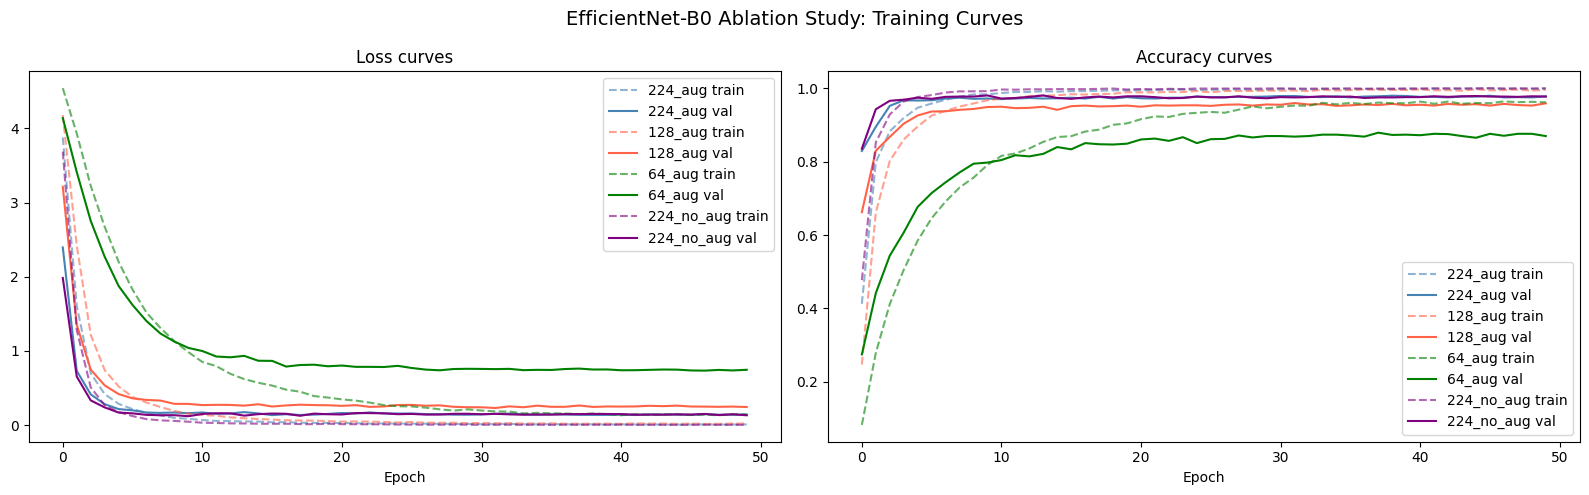

In [10]:
# ── Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ["steelblue", "tomato", "green", "purple"]

for i, (name, res) in enumerate(all_results.items()):
    h = res["history"]
    axes[0].plot(h["train_loss"], linestyle="--", color=colors[i], alpha=0.6, label=f"{name} train")
    axes[0].plot(h["val_loss"],   linestyle="-",  color=colors[i],            label=f"{name} val")
    axes[1].plot(h["train_acc"],  linestyle="--", color=colors[i], alpha=0.6, label=f"{name} train")
    axes[1].plot(h["val_acc"],    linestyle="-",  color=colors[i],            label=f"{name} val")

axes[0].set_title("Loss curves");     axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Accuracy curves"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.suptitle("EfficientNet-B0 Ablation Study: Training Curves", fontsize=14)
plt.tight_layout()
plt.savefig("efficientnet_b0_training_curves.png", dpi=100, bbox_inches="tight")
plt.show()

In [11]:
# ── Evaluation helpers
@torch.no_grad()
def get_predictions(model, loader):
    """Run inference, return true labels, predicted labels, and softmax probs."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())
        all_probs.append(probs)
    return (
        np.concatenate(all_labels),
        np.concatenate(all_preds),
        np.concatenate(all_probs)
    )


def top5_accuracy(labels, probs):
    """Correct if true label appears in top-5 predicted classes."""
    top5    = np.argsort(probs, axis=1)[:, -5:]
    correct = sum(labels[i] in top5[i] for i in range(len(labels)))
    return correct / len(labels)


def full_evaluation(name, model, test_dl):
    """Compute and print all evaluation metrics."""
    print(f"\n{'='*60}")
    print(f"Evaluation: {name}")
    print(f"{'='*60}")

    y_true, y_pred, y_probs = get_predictions(model, test_dl)

    acc  = accuracy_score(y_true, y_pred)
    top5 = top5_accuracy(y_true, y_probs)
    print(f"Overall Accuracy : {acc:.4f}")
    print(f"Top-5 Accuracy   : {top5:.4f}")

    p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
    p_wt,  r_wt,  f_wt,  _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    print(f"Macro    — P: {p_mac:.4f}  R: {r_mac:.4f}  F1: {f_mac:.4f}")
    print(f"Weighted — P: {p_wt:.4f}  R: {r_wt:.4f}  F1: {f_wt:.4f}")

    report = classification_report(y_true, y_pred, target_names=class_names,
                                   output_dict=True, zero_division=0)
    per_class_acc = {cls: report[cls]["recall"] for cls in class_names}
    worst5 = sorted(per_class_acc.items(), key=lambda x:  x[1])[:5]
    best5  = sorted(per_class_acc.items(), key=lambda x: -x[1])[:5]
    print(f"\nTop-5 best  classes: {best5}")
    print(f"Top-5 worst classes: {worst5}")

    return y_true, y_pred, {
        "acc": acc, "top5": top5,
        "macro_f1": f_mac, "weighted_f1": f_wt,
        "per_class_acc": per_class_acc
    }

In [12]:
# ── Run evaluation on all configs
eval_results = {}

for name, res in all_results.items():
    _, _, test_dl = res["loaders"]
    y_true, y_pred, metrics = full_evaluation(name, res["model"].to(DEVICE), test_dl)
    eval_results[name] = {"y_true": y_true, "y_pred": y_pred, "metrics": metrics}


Evaluation: 224_aug
Overall Accuracy : 0.9724
Top-5 Accuracy   : 0.9977
Macro    — P: 0.9607  R: 0.9559  F1: 0.9543
Weighted — P: 0.9749  R: 0.9724  F1: 0.9716

Top-5 best  classes: [('Faces', 1.0), ('Faces_easy', 1.0), ('Leopards', 1.0), ('Motorbikes', 1.0), ('accordion', 1.0)]
Top-5 worst classes: [('octopus', 0.4), ('lobster', 0.5), ('cougar_body', 0.5714285714285714), ('crocodile_head', 0.75), ('elephant', 0.8)]

Evaluation: 128_aug
Overall Accuracy : 0.9562
Top-5 Accuracy   : 0.9962
Macro    — P: 0.9390  R: 0.9356  F1: 0.9323
Weighted — P: 0.9610  R: 0.9562  F1: 0.9554

Top-5 best  classes: [('Leopards', 1.0), ('Motorbikes', 1.0), ('accordion', 1.0), ('airplanes', 1.0), ('barrel', 1.0)]
Top-5 worst classes: [('octopus', 0.2), ('lotus', 0.5), ('cougar_body', 0.5714285714285714), ('crab', 0.6363636363636364), ('brontosaurus', 0.6666666666666666)]

Evaluation: 64_aug
Overall Accuracy : 0.8571
Top-5 Accuracy   : 0.9624
Macro    — P: 0.8079  R: 0.7964  F1: 0.7893
Weighted — P: 0.8686 

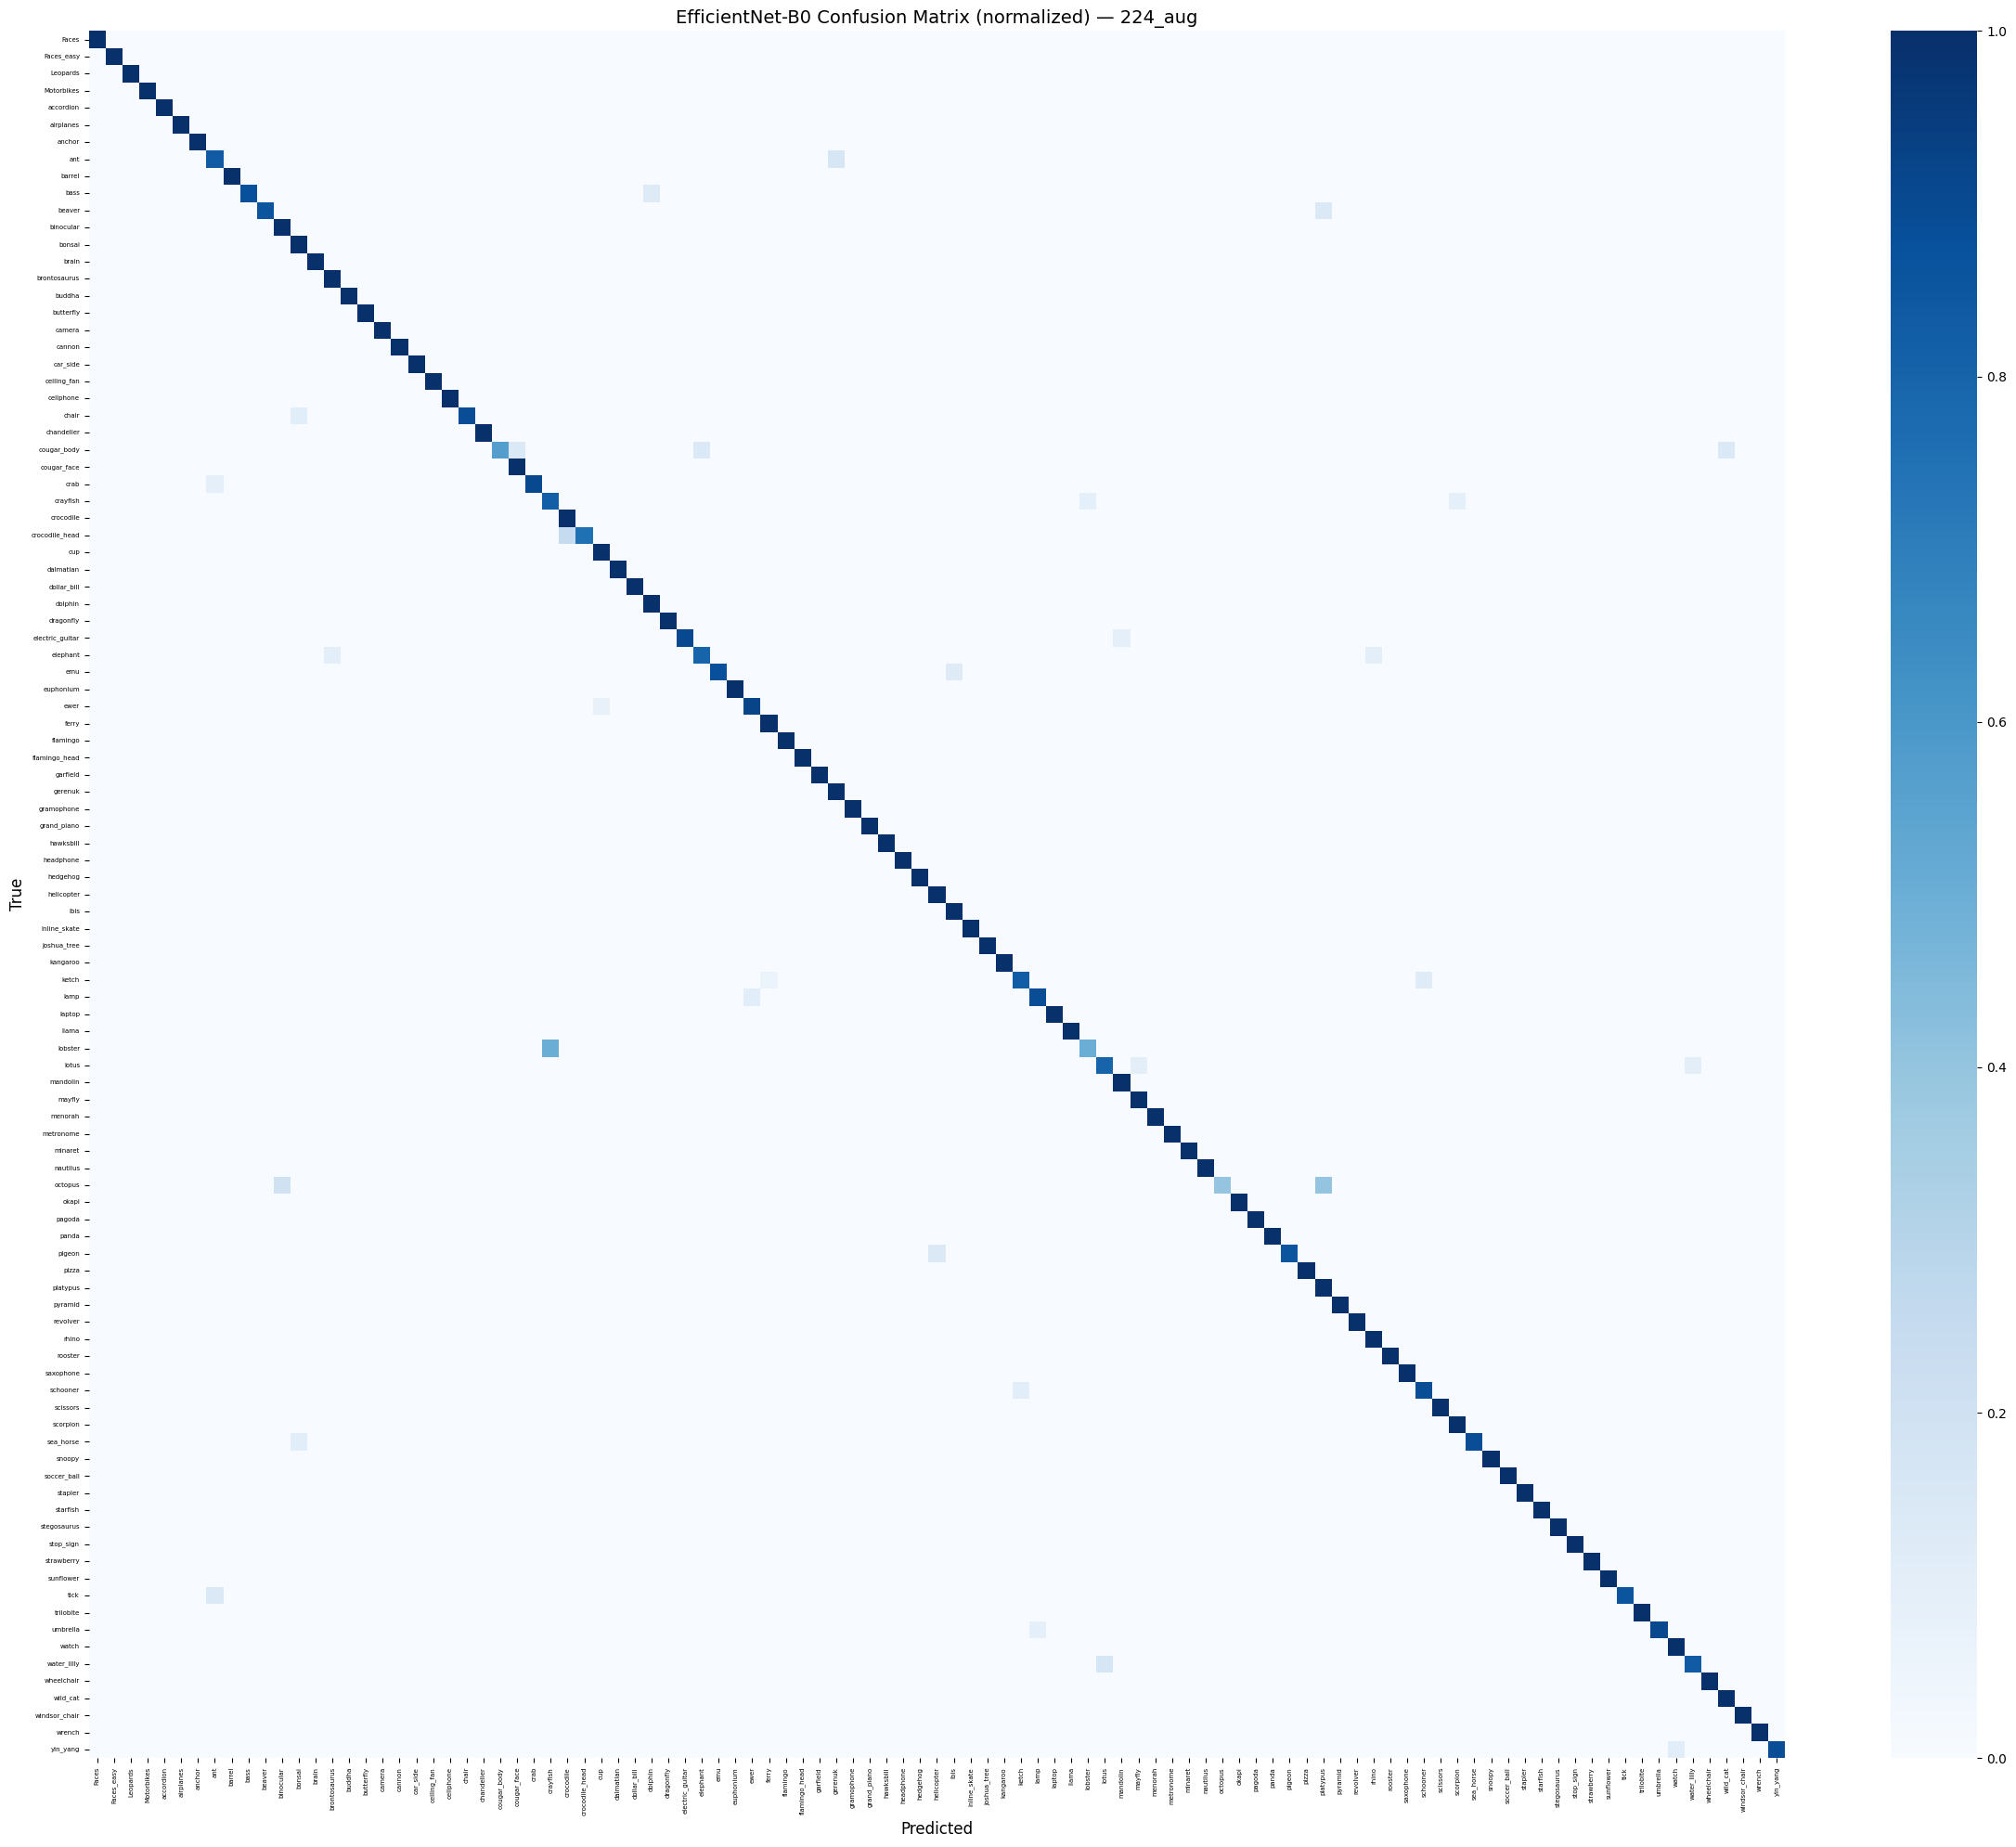

In [13]:
# ── Confusion matrix — baseline config only
baseline_name = "224_aug"
y_true = eval_results[baseline_name]["y_true"]
y_pred = eval_results[baseline_name]["y_pred"]

cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalize by true class

fig, ax = plt.subplots(figsize=(24, 20))
sns.heatmap(cm_norm, ax=ax, cmap="Blues", xticklabels=class_names,
            yticklabels=class_names, vmin=0, vmax=1)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"EfficientNet-B0 Confusion Matrix (normalized) — {baseline_name}", fontsize=14)
plt.xticks(rotation=90, fontsize=5)
plt.yticks(rotation=0,  fontsize=5)
plt.tight_layout()
plt.savefig("efficientnet_b0_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

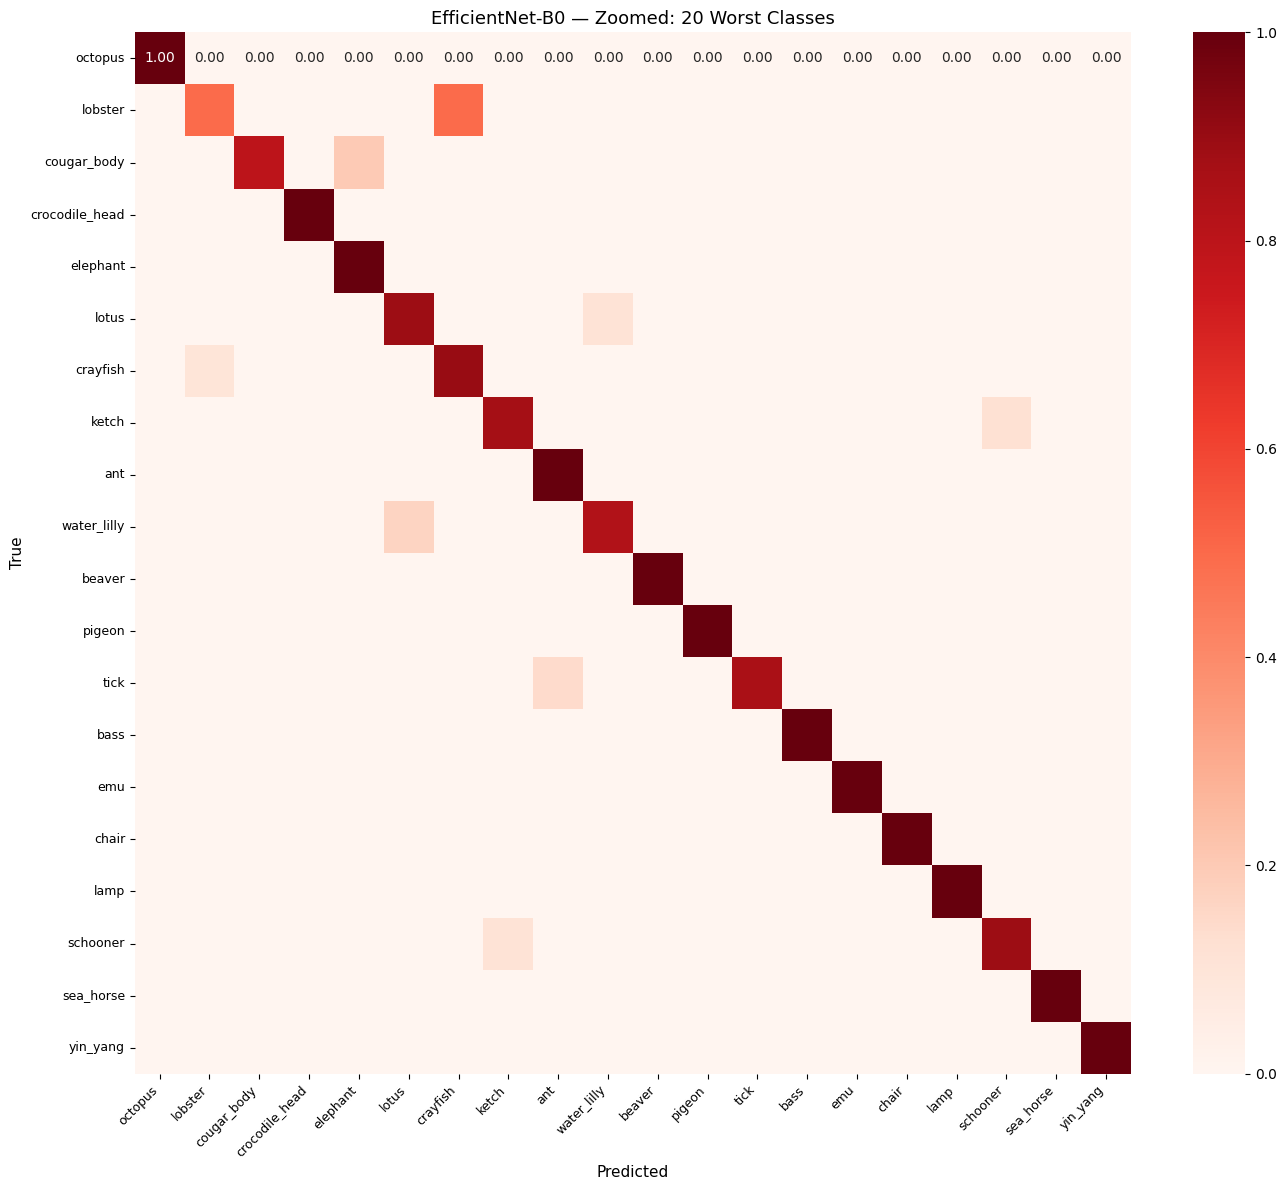

Worst 20 classes: ['octopus', 'lobster', 'cougar_body', 'crocodile_head', 'elephant', 'lotus', 'crayfish', 'ketch', 'ant', 'water_lilly', 'beaver', 'pigeon', 'tick', 'bass', 'emu', 'chair', 'lamp', 'schooner', 'sea_horse', 'yin_yang']


In [14]:
# ── Zoomed confusion matrix: worst-performing classes only
# Much more readable than the full 101×101 matrix
N_WORST = 20  # focus on the 20 most confused classes

per_class_acc = eval_results[baseline_name]["metrics"]["per_class_acc"]
worst_classes = [cls for cls, _ in sorted(per_class_acc.items(), key=lambda x: x[1])[:N_WORST]]
worst_indices = [class_names.index(c) for c in worst_classes]

# Slice the full confusion matrix to worst classes only
cm_worst      = cm[np.ix_(worst_indices, worst_indices)]
cm_worst_norm = cm_worst.astype(float) / (cm_worst.sum(axis=1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_worst_norm, ax=ax, cmap="Reds", annot=True, fmt=".2f",
            xticklabels=worst_classes, yticklabels=worst_classes, vmin=0, vmax=1)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.set_title(f"EfficientNet-B0 — Zoomed: {N_WORST} Worst Classes", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig("efficientnet_b0_confusion_matrix_worst20.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Worst {N_WORST} classes: {worst_classes}")

In [15]:
# ── Ablation comparison table
rows = []
for name, res in eval_results.items():
    m = res["metrics"]
    rows.append({
        "Config"     : name,
        "Accuracy"   : f"{m['acc']:.4f}",
        "Top-5 Acc"  : f"{m['top5']:.4f}",
        "Macro F1"   : f"{m['macro_f1']:.4f}",
        "Weighted F1": f"{m['weighted_f1']:.4f}",
    })

df = pd.DataFrame(rows)
print("\n📊 EfficientNet-B0 Ablation Results:")
print(df.to_string(index=False))
df.to_csv("efficientnet_b0_ablation_results.csv", index=False)


📊 EfficientNet-B0 Ablation Results:
    Config Accuracy Top-5 Acc Macro F1 Weighted F1
   224_aug   0.9724    0.9977   0.9543      0.9716
   128_aug   0.9562    0.9962   0.9323      0.9554
    64_aug   0.8571    0.9624   0.7893      0.8556
224_no_aug   0.9724    0.9977   0.9522      0.9714


In [16]:
# ── Save results for final report
report_data = {
    name: {
        "y_true" : res["y_true"],
        "y_pred" : res["y_pred"],
        "metrics": res["metrics"],
        "history": all_results[name]["history"],
    }
    for name, res in eval_results.items()
}

with open("efficientnet_b0_results.pkl", "wb") as f:
    pickle.dump(report_data, f)

print("efficientnet_b0_results.pkl saved — will be used in the final report.")
print("\nShare the ablation table above and confirm before we move to Classical ML!")

efficientnet_b0_results.pkl saved — will be used in the final report.

Share the ablation table above and confirm before we move to Classical ML!
